### Data Science Semester 2 Exam Project
#### Project Title: Technical Job Interview

### The Tech Talent Premium

*Scenario* 
- A Global Data Science and AI ecosystem tech talent company.
- Hoping to decode what drives salaries across global tech roles

*Wants to investigate:*
- Which roles and industries pay the most
- How education, skills, certifications, and remote work and company size relates with pay
- Does more experience always mean more money

### 1. Load & Inspect the Dataset

In [1]:
# Import the libraries for the data workflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_1samp
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1)

In [2]:
# Read dataset of interest
jobs_df = pd.read_csv("job_salary_prediction_dataset.csv")

In [3]:
# Examine the dataset
# View the top 12 rows
jobs_df.head(12)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


In [4]:
# rename experience_years to years_of_experience for intuition purpose
jobs_df.rename(columns={'experience_years':'years_of_experience'}, inplace = True)

In [5]:
jobs_df.head()

,job_title,years_of_experience,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [6]:
# A health report of the dataset
print(f"Dataset Shape: {jobs_df.shape[0]:,} rows and {jobs_df.shape[1]} columns")
jobs_df.info()

Dataset Shape: 250,000 rows and 10 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   job_title            250000 non-null  object
 1   years_of_experience  250000 non-null  int64 
 2   education_level      250000 non-null  object
 3   skills_count         250000 non-null  int64 
 4   industry             250000 non-null  object
 5   company_size         250000 non-null  object
 6   location             250000 non-null  object
 7   remote_work          250000 non-null  object
 8   certifications       250000 non-null  int64 
 9   salary               250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [7]:
# Check for missing values in the dataset
missing = jobs_df.isnull().sum()
print(missing)
print(f"\nTotal missing values in dataset: {missing.sum()}")

job_title              0
years_of_experience    0
education_level        0
skills_count           0
industry               0
company_size           0
location               0
remote_work            0
certifications         0
salary                 0
dtype: int64

Total missing values in dataset: 0


In [8]:
# Check the unique value counts for categorical colums to ensure there are no mislabeling of values
cat_cols = jobs_df.select_dtypes(include = 'object').columns

for col in cat_cols:
    print(f"\n{col.title()} ({jobs_df[col].nunique()} unique values):")
    print(jobs_df[col].value_counts().to_string())


Job_Title (12 unique values):
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633

Education_Level (5 unique values):
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776

Industry (10 unique values):
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841

Company_Size (5 unique values):
Large         50254
Small         50235
Medium        50027
Enterprise    49875
Startup       49609

Location (10 u

*There is no mislabelling of the datatype of any value in the categorical columns. This proves the completeness of the dataset.*

In [9]:
# Get the descriptive statistics for numerical columns
jobs_df.describe()

,years_of_experience,skills_count,certifications,salary
count,"250,000.00","250,000.00","250,000.00","250,000.00"
mean,10.01,10.00,2.49,"145,718.08"
std,6.06,5.48,1.71,"37,407.95"
min,0.00,1.00,0.00,"31,867.00"
25%,5.00,5.00,1.00,"119,358.00"
50%,10.00,10.00,2.00,"143,453.00"
75%,15.00,15.00,4.00,"169,492.00"
max,20.00,19.00,5.00,"333,046.00"


**Observations from Inspection**
- The dataset contains 250,000 rows and 10 columns, making it a large dataset for analysis.
- There are 6 categorical variables (objects) and 4 numerical variables (integers) in the dataset.

*Categorical columns/variables in the dataset includes:*
- job_title
- education_level
- industry
- company size
- location
- remote_work

*Numerical columns/variables in the dataset includes:*
- years_of_experience
- skills_count
- certifications
- salary

*Missing values*
- There are no missing values in the dataset.The dataset is complete when loaded. A check for datatype mislabelling (for e.g None as object), but there was no observed mislabelling.
- All categorical columns had unique values not including "None or null".

*Descriptive Statistics*
- The years_of_experience ranges from 0 - 20 years with a mean of 10 years and standard deviation of 6 years .
- Skills_count ranges from 1 - 19 skills with a mean of approximately 10 skills.
- Certifcation ranges from 0 - 5 certifications.
- Salary (which will be our target variable) ranges from 31,867 - 333,046 usd with a mean of approximately 145,718 usd and standard deviation of about 37,408 usd.

**Key Takeaway**
- There are 12 unique job titles spanning data, engineering, and business roles.
- Salary is skewed to the right (mean > std). This might be due to a handful of roles having a very high pay.
- There are no missing values in the dataset which means we will have to simulate missingness to demonstrate imputation.
- Certifications is an integer count (0 - 5), not a flag(i.e whether the individual has certification or not).

### 2. Data Wrangling & Subsetting

In [10]:
# we will narrow our focus on data and AI roles
# subset job_title to show only: Data Analyst, Data Scientist, Machine learning Engineer, and AI Engineer
target_roles = ['Data Analyst', 'Data Scientist', 'Machine Learning Engineer', 'AI Engineer']

In [11]:
# Jobs_subset
jobs_subset = jobs_df[jobs_df['job_title'].isin(target_roles)].copy()
jobs_subset.reset_index(drop = True, inplace = True)

print(f"Subset Shape: {jobs_subset.shape[0]:,} rows and {jobs_subset.shape[1]} columns")
print(jobs_subset['job_title'].value_counts())

Subset Shape: 83,234 rows and 10 columns
AI Engineer                  20945
Data Scientist               20890
Data Analyst                 20722
Machine Learning Engineer    20677
Name: job_title, dtype: int64


**Feature Engineering**

*1. Experience Level*
- We will group exact years of work experience into broad categories like:
- "Entry (0-2 yrs)", "Mid-Level (3-7 yrs)", "Senior (8-13 yrs)" and "Expert (14-20 yrs)".
- This makes it much easier to compare typical salaries between different groups.
- And helps us see clear patterns in the data that might be hidden by individual numbers.

In [12]:
# Experience Level
bins = [-1, 2, 7, 13, 20]
labels = ['Entry (0-2 yrs)', 'Mid-level (3-7 yrs)', 'Senior (8-13 yrs)', 'Expert (14-20 yrs)']

jobs_subset['experience_level'] = pd.cut(jobs_subset['years_of_experience'], bins = bins, labels = labels)
# pd.cut() is used to segment the jobs_subset and sort values into bins

print("Experience Level distribution:")
print(jobs_subset['experience_level'].value_counts().sort_index(ascending = False))

Experience Level distribution:
Expert (14-20 yrs)     27965
Senior (8-13 yrs)      23549
Mid-level (3-7 yrs)    19761
Entry (0-2 yrs)        11959
Name: experience_level, dtype: int64


*2. Skill_to_cert_ratio*

- The skill_to_cert_ratio will help us compare the variety of skills a person has againgst the number of official certificates they've earned.
- A high ratio suggests a "Generalist" i.e someone who knows a little bit of everything but do not have formal paperwork for all of it.
- A low ratio suggests a "Certified Specialist" i.e someone who focuses deeply on specific areas and has the official qualifications to prove it.
- This helps us categorize canditates more accurately and predict which roles they are best suited for.

In [13]:
# Skill_to_cert_ratio
jobs_subset['skill_to_cert_ratio'] = jobs_subset['skills_count'] / (jobs_subset['certifications'] + 1)
# +1 avoids division by zero

print("Skill-to-Cert Ratio summary:")
print(jobs_subset['skill_to_cert_ratio'].describe())

Skill-to-Cert Ratio summary:
count   83,234.00
mean         4.08
std          3.95
min          0.17
25%          1.50
50%          2.83
75%          5.00
max         19.00
Name: skill_to_cert_ratio, dtype: float64


*3. Salary Tier*
- We will divide salaries into four tiers: Low, Medium, High, and Premium using quantiles.
- This will help us see what percentage of different groups earn the highest pay.

In [14]:
salary_quantiles = jobs_subset['salary'].quantile([0.33, 0.66, 0.90])
q33, q66, q90 = salary_quantiles[0.33], salary_quantiles[0.66], salary_quantiles[0.90]

def assign_tier(x):
    if x < q33: return 'Low'
    elif x < q66: return 'Medium'
    elif x < q90: return 'High'
    else:
        return 'Premium'
    
jobs_subset['salary_tier'] = jobs_subset['salary'].apply(assign_tier)
jobs_subset['salary_tier'] = pd.Categorical(jobs_subset['salary_tier'],
                                categories=['Low','Medium','High','Premium'],ordered=True)

print(f"Quantile thresholds:\nLow: < ${q33:,.0f}\nMedium: < ${q66:,.0f}\nHigh: < ${q90:,.0f}\nPremium: ≥ ${q90:,.0f}")
print("\nSalary Tier distribution:")
print(jobs_subset['salary_tier'].value_counts().sort_index())

Quantile thresholds:
Low: < $131,315
Medium: < $165,981
High: < $204,143
Premium: ≥ $204,143

Salary Tier distribution:
Low        27467
Medium     27467
High       19975
Premium     8325
Name: salary_tier, dtype: int64


In [15]:
# View the featured dataset top 10 rows
jobs_subset[['job_title','experience_level','skill_to_cert_ratio','salary_tier']].head(10)

,job_title,experience_level,skill_to_cert_ratio,salary_tier
0,AI Engineer,Senior (8-13 yrs),0.67,Low
1,Data Analyst,Mid-level (3-7 yrs),17.00,Low
2,AI Engineer,Entry (0-2 yrs),1.33,High
3,Machine Learning Engineer,Mid-level (3-7 yrs),3.00,High
4,AI Engineer,Mid-level (3-7 yrs),14.00,High
5,Data Analyst,Mid-level (3-7 yrs),0.60,Low
6,Machine Learning Engineer,Senior (8-13 yrs),4.00,High
7,Data Scientist,Entry (0-2 yrs),2.33,Low
8,Data Scientist,Senior (8-13 yrs),3.00,Low
9,Machine Learning Engineer,Expert (14-20 yrs),2.50,Premium


In [16]:
# Read into a new dataframe for future refernce
jobs_subset_new = jobs_subset[['job_title','experience_level','skill_to_cert_ratio','salary_tier']]
jobs_subset_new.head()

,job_title,experience_level,skill_to_cert_ratio,salary_tier
0,AI Engineer,Senior (8-13 yrs),0.67,Low
1,Data Analyst,Mid-level (3-7 yrs),17.00,Low
2,AI Engineer,Entry (0-2 yrs),1.33,High
3,Machine Learning Engineer,Mid-level (3-7 yrs),3.00,High
4,AI Engineer,Mid-level (3-7 yrs),14.00,High


### 3. Handling Missing Data

*The original dataset contains no missing values.*

*To demonstrate handling missing data and imputation we will:*
    
- Simulate missingness by randomly nullifying values.
- And apply appropraite imputation strategy based on data type.

In [17]:
# Simulating missingness
np.random.seed(42)
jobs_missing_sim = jobs_df.copy()

In [18]:
jobs_missing_sim

,job_title,years_of_experience,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [19]:
# Intoduce missingness in the following columns: 
# years_of_experience, education_level, certifications and industry

for col, pct in [('years_of_experience', 0.05), ('education_level', 0.1),
                 ('certifications', 0.04), ('industry', 0.07)]:
    n_null = int(len(jobs_missing_sim) * pct)
    null_idx = np.random.choice(jobs_missing_sim.index, size = n_null, replace = False) # This generates a random sample from the given array
    jobs_missing_sim.loc[null_idx, col] = np.nan
    
print("Simulated Missing Value Report:")
missing_sim = jobs_missing_sim[['years_of_experience','education_level','certifications','industry']].isnull().sum()
missing_pct_sim = (missing_sim / len(jobs_missing_sim) * 100)
print(pd.DataFrame({'Count': missing_sim, '% Missing': missing_pct_sim}))

print(f"\nTotal missing values before imputation: {jobs_missing_sim.isnull().sum().sum()}")

Simulated Missing Value Report:
                     Count  % Missing
years_of_experience  12500       5.00
education_level      25000      10.00
certifications       10000       4.00
industry             17500       7.00

Total missing values before imputation: 65000


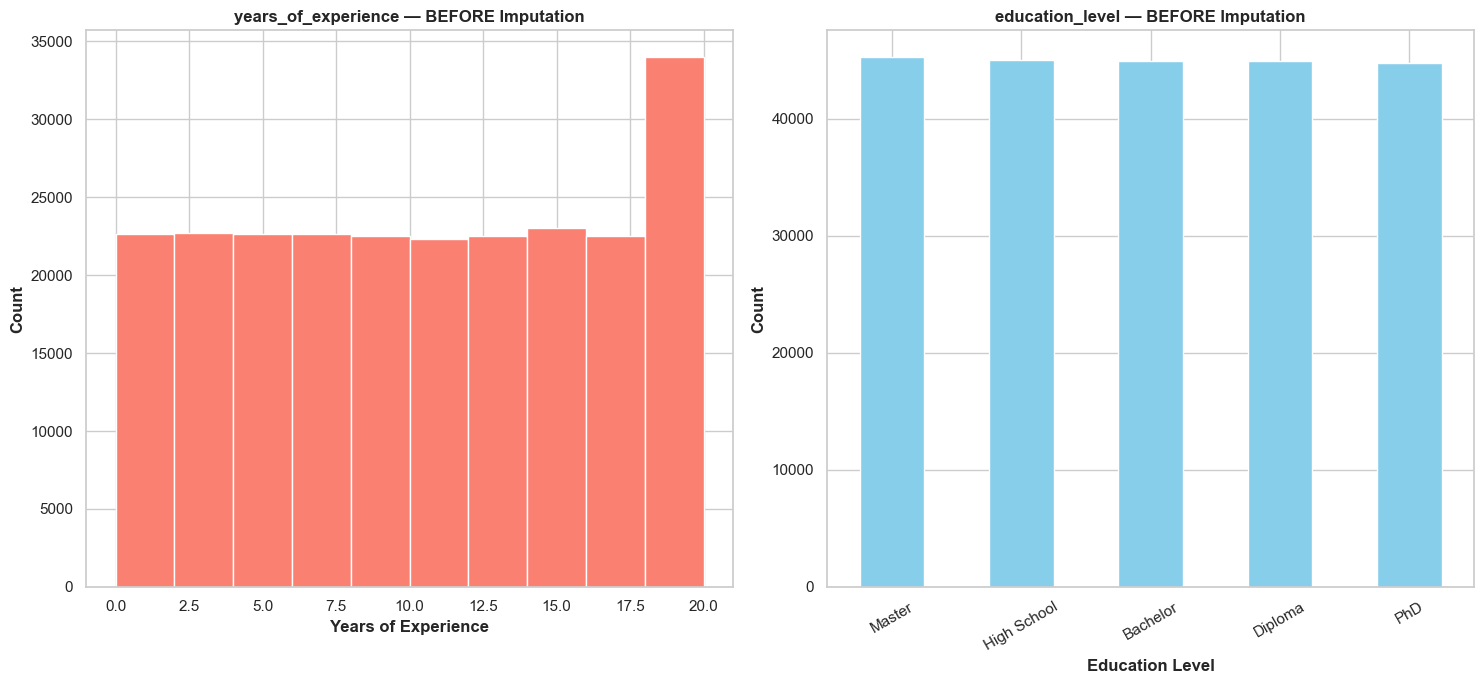

In [56]:
# visualize to see view the distribution before imputation
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].hist(jobs_missing_sim['years_of_experience'].dropna(), bins=10, color='salmon', edgecolor = 'white')
axes[0].set_title('years_of_experience — BEFORE Imputation', fontweight = 'bold')
axes[0].set_xlabel('Years of Experience', fontweight = 'bold')
axes[0].set_ylabel('Count', fontweight = 'bold')

jobs_missing_sim['education_level'].value_counts().plot(kind='bar', ax=axes[1],
    color='skyblue', rot = 30)
axes[1].set_title('education_level — BEFORE Imputation', fontweight = 'bold')
axes[1].set_xlabel('Education Level', fontweight = 'bold')
axes[1].set_ylabel('Count', fontweight = 'bold')

plt.tight_layout()
plt.show()

In [21]:
# Apply imputation strategies
sim_filled = jobs_missing_sim.copy()

# For missing numerical columns: years_of_experience and certifications
# We will impute missing values with median
# This is because the median is more robust to outliers than the mean

for col in ['years_of_experience', 'certifications']:
    median_val = sim_filled[col].median()
    before_count = sim_filled[col].isnull().sum()
    sim_filled[col].fillna(median_val, inplace=True)
    print(f"\n{col.title()}: {before_count} missing values filled with median = {median_val}")


Years_Of_Experience: 12500 missing values filled with median = 10.0

Certifications: 10000 missing values filled with median = 2.0


In [22]:
# For missing Categorical columns: education_level and industry
# We will impute missing values with mode
# This is because mode is the only statistically meaningful central tendency for categorical variables

for col in ['education_level', 'industry']:
    mode_val = sim_filled[col].mode()[0]
    before_count = sim_filled[col].isnull().sum()
    sim_filled[col].fillna(mode_val, inplace=True)
    print(f"\n{col.title()}: {before_count} missing values filled with mode = {mode_val}")


Education_Level: 25000 missing values filled with mode = Master

Industry: 17500 missing values filled with mode = Finance


In [23]:
# Check for missingness after imputation
print(f"Total missing values after imputation: {sim_filled.isnull().sum().sum()}")

Total missing values after imputation: 0


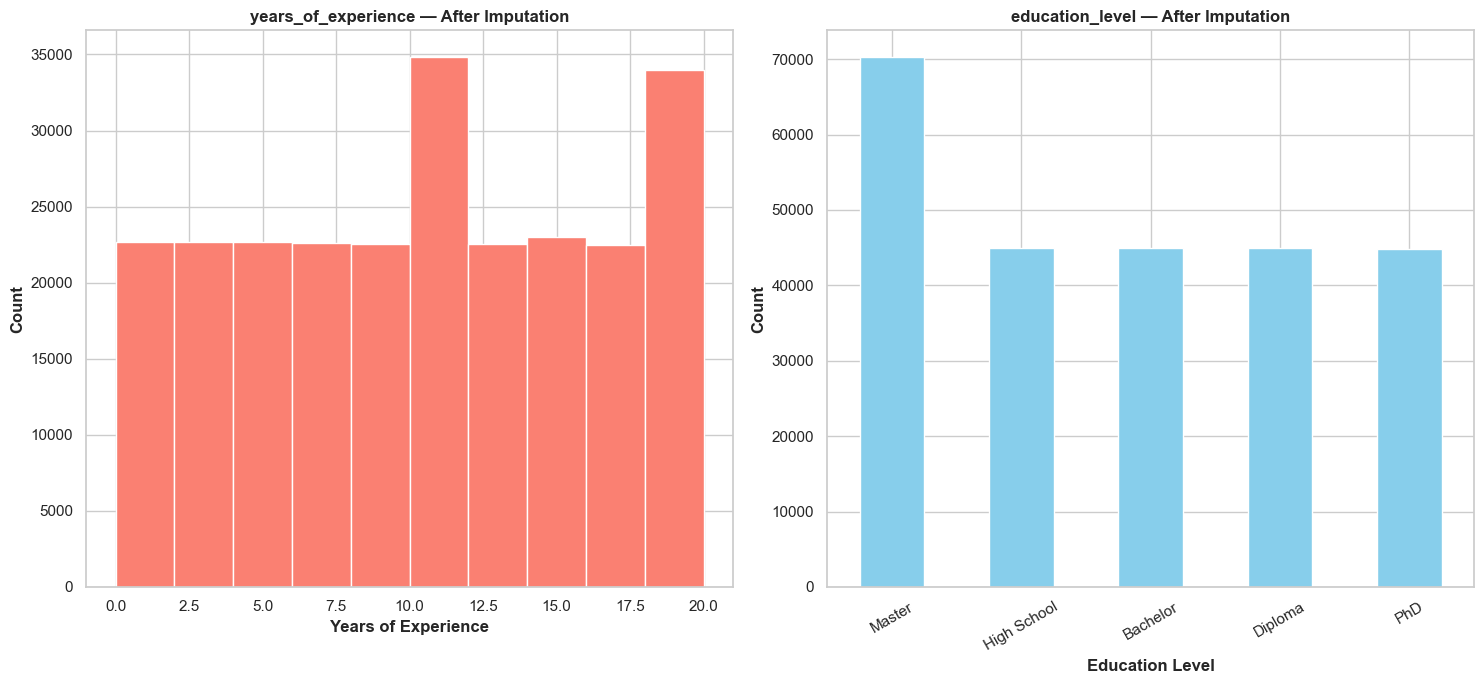

In [57]:
# visualize to see view the distribution after imputation
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].hist(sim_filled['years_of_experience'], bins=10, color='salmon', edgecolor = 'white')
axes[0].set_title('years_of_experience — After Imputation', fontweight = 'bold')
axes[0].set_xlabel('Years of Experience', fontweight = 'bold')
axes[0].set_ylabel('Count', fontweight = 'bold')

sim_filled['education_level'].value_counts().plot(kind='bar', ax=axes[1],
    color='skyblue', rot = 30)
axes[1].set_title('education_level — After Imputation', fontweight = 'bold')
axes[1].set_xlabel('Education Level', fontweight = 'bold')
axes[1].set_ylabel('Count', fontweight = 'bold')

plt.tight_layout()
plt.show()

### 4. Statistical Imputation for Outliers

**Outlier Detection**
- we will focus on the salary column which will be the primary column of interest.
- we will make use of the Z-score method to detect outliers.


*The Z-score also called the standard score shows how far a data point is from the mean in terms of standard deviation*
- If the Z-score is greater than a chosen threshold, the value is considered an outlier.


**Outlier Removal**
- we will make use of the trimming method for outlier removal.
- Trimming removes the rows that contain outliers from the column.
- Trimming is appropriate here because the flagged records might represent data quality anomalies.
- Such anomalies might be extreme salary values that cannot be explained by roles, experience or other independent variables.
- Retaining them would distort the statistical distribution by pulling outliers towards the center which will affect the relationship we are trying to study.

In [25]:
# Computing Z-scores for salary
salary_mean = jobs_subset['salary'].mean()
salary_std = jobs_subset['salary'].std()

jobs_subset['salary_zscore'] = np.abs(stats.zscore(jobs_subset['salary']))
# np.abs ensures the values are always positive
jobs_subset['salary_zscore'].describe()

count   83,234.00
mean         0.80
std          0.60
min          0.00
25%          0.32
50%          0.68
75%          1.16
max          4.50
Name: salary_zscore, dtype: float64

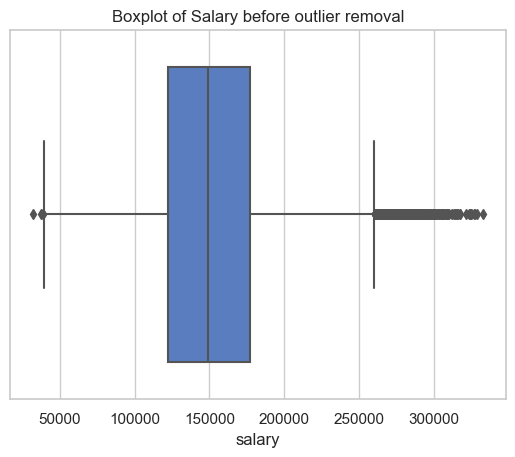

In [26]:
# visualize salary for outliers
sns.boxplot(x= jobs_subset['salary'])
plt.title('Boxplot of Salary before outlier removal')
plt.show()

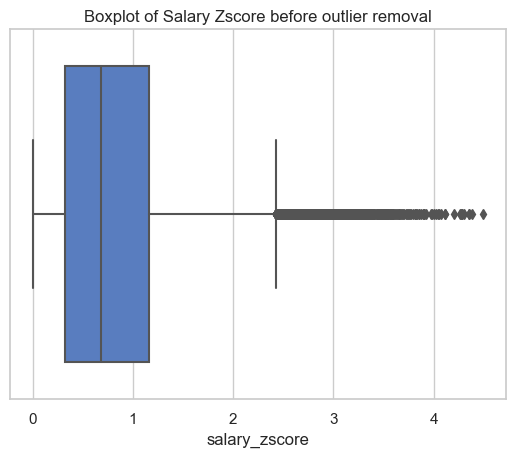

In [27]:
sns.boxplot(x= jobs_subset['salary_zscore'])
plt.title('Boxplot of Salary Zscore before outlier removal')
plt.show()

In [28]:
# set the standard threshold of 2.3. This is assumed from the above box plot of zscore
threshold_z = 2.3

# Rule: outliers = threshold_z > 2.3
outlier_mask = jobs_subset['salary_zscore'] > threshold_z
outliers_z = jobs_subset[outlier_mask]

print(f"Z-Score Outlier Detection:  (threshold = |Z| > {threshold_z})")
print(f"\nOutliers detected = {len(outliers_z):,} ({len(outliers_z)/len(jobs_subset)*100:.3f}% of subset)")
print("\nOutlier salary summary:")
print(outliers_z['salary'].describe())

Z-Score Outlier Detection:  (threshold = |Z| > 2.3)

Outliers detected = 1,609 (1.933% of subset)

Outlier salary summary:
count     1,609.00
mean    237,249.57
std      69,029.26
min      31,867.00
25%     247,176.00
50%     255,020.00
75%     267,815.00
max     333,046.00
Name: salary, dtype: float64


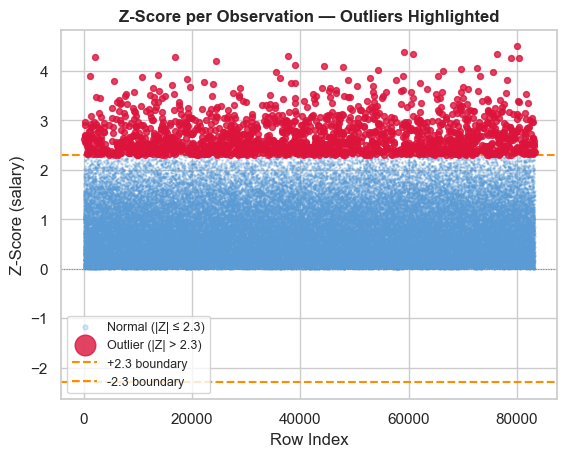

In [58]:
# Visualise Z-scores — flag outliers on scatter
fig, ax = plt.subplots()

# Z-score scatter plot — each point is one employee record
normal_mask = ~outlier_mask
ax.scatter(jobs_subset.loc[normal_mask].index, jobs_subset.loc[normal_mask, 'salary_zscore'],
                s=1, alpha=0.25, color='#5B9BD5', label='Normal (|Z| ≤ 2.3)')
ax.scatter(jobs_subset.loc[outlier_mask].index, jobs_subset.loc[outlier_mask, 'salary_zscore'],
                s=18, alpha=0.8, color='crimson', zorder=5, label=f'Outlier (|Z| > {threshold_z})')
ax.axhline( threshold_z, color='darkorange', linestyle='--', linewidth=1.5, label=f'+{threshold_z} boundary')
ax.axhline(-threshold_z, color='darkorange', linestyle='--', linewidth=1.5, label=f'-{threshold_z} boundary')
ax.axhline(0, color='grey', linewidth=0.7, linestyle=':')
plt.title('Z-Score per Observation — Outliers Highlighted', fontweight='bold')
plt.xlabel('Row Index')
plt.ylabel('Z-Score (salary)')
plt.legend(fontsize=9, markerscale=3.5)

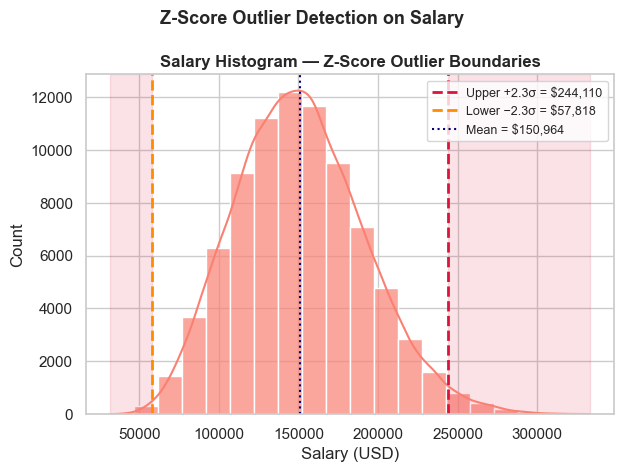

In [30]:
# Visualise Salary histogram with Z-score boundary lines
fig, ax = plt.subplots()

upper_z_boundary = salary_mean + threshold_z * salary_std
lower_z_boundary = salary_mean - threshold_z * salary_std

sns.histplot(jobs_subset['salary'], bins=20, kde=True, ax= ax, color='salmon', edgecolor='white', alpha=0.7)
ax.axvline(upper_z_boundary, color='crimson', linestyle='--', linewidth=2,
                label=f'Upper +2.3σ = ${upper_z_boundary:,.0f}')
ax.axvline(lower_z_boundary, color='darkorange', linestyle='--', linewidth=2,
                label=f'Lower −2.3σ = ${lower_z_boundary:,.0f}')
ax.axvline(salary_mean, color='navy', linewidth=1.5, linestyle=':',
                label=f'Mean = ${salary_mean:,.0f}')
ax.axvspan(jobs_subset['salary'].min(), lower_z_boundary, alpha=0.12, color='crimson')
ax.axvspan(upper_z_boundary, jobs_subset['salary'].max(), alpha=0.12, color='crimson')
plt.title('Salary Histogram — Z-Score Outlier Boundaries', fontweight='bold')
plt.xlabel('Salary (USD)')
plt.legend(fontsize=9)

plt.suptitle('Z-Score Outlier Detection on Salary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Inspect the flagged outliers before removing them
print(f"Sample of flagged outlier records (|Z| > {threshold_z}):")
display_cols = ['job_title', 'years_of_experience', 'education_level', 'salary', 'salary_zscore']
display_cols = outliers_z[display_cols].sort_values('salary_zscore', ascending=False)
display_cols.head(20)

Sample of flagged outlier records (|Z| > 2.3):


,job_title,years_of_experience,education_level,salary,salary_zscore
80023,AI Engineer,20,PhD,333046,4.50
59099,AI Engineer,19,PhD,328616,4.39
76314,AI Engineer,18,PhD,327217,4.35
60772,AI Engineer,17,PhD,327025,4.35
37670,AI Engineer,19,PhD,325052,4.30
16919,AI Engineer,20,PhD,324583,4.29
2002,AI Engineer,19,PhD,324505,4.29
80300,AI Engineer,18,PhD,323985,4.27
78863,AI Engineer,18,PhD,323423,4.26
24376,AI Engineer,17,PhD,321127,4.20


In [32]:
display_cols.tail(20)

,job_title,years_of_experience,education_level,salary,salary_zscore
56968,AI Engineer,15,Bachelor,244329,2.31
47828,AI Engineer,15,PhD,244261,2.30
6269,Data Analyst,3,High School,57678,2.30
69209,Machine Learning Engineer,19,High School,244243,2.30
64827,Machine Learning Engineer,19,Master,244237,2.30
46340,AI Engineer,18,Master,244233,2.30
48207,Machine Learning Engineer,3,PhD,244223,2.30
42576,AI Engineer,20,High School,244220,2.30
10091,Data Analyst,1,Diploma,57716,2.30
40407,AI Engineer,9,PhD,244208,2.30


In [33]:
# drop all rows flagged as outliers
n_before = len(jobs_subset)

jobs_trimmed = jobs_subset[~outlier_mask].copy()
jobs_trimmed.reset_index(drop=True, inplace=True)

n_after   = len(jobs_trimmed)
n_removed = n_before - n_after

print(f"Trimming Summary")
print(f"Rows before trimming : {n_before:,}")
print(f"Outlier rows removed : {n_removed:,} ({n_removed/n_before*100:.2f}%)")
print(f"Rows after trimming  : {n_after:,}")
print()
print(f"Salary before :— Mean: ${jobs_subset['salary'].mean():,.2f} | Std: ${jobs_subset['salary'].std():,.2f}")
print(f"Salary after:— Mean: ${jobs_trimmed['salary'].mean():,.2f} | Std: ${jobs_trimmed['salary'].std():,.2f}")

Trimming Summary
Rows before trimming : 83,234
Outlier rows removed : 1,609 (1.93%)
Rows after trimming  : 81,625

Salary before :— Mean: $150,964.29 | Std: $40,498.28
Salary after:— Mean: $149,263.43 | Std: $37,801.00


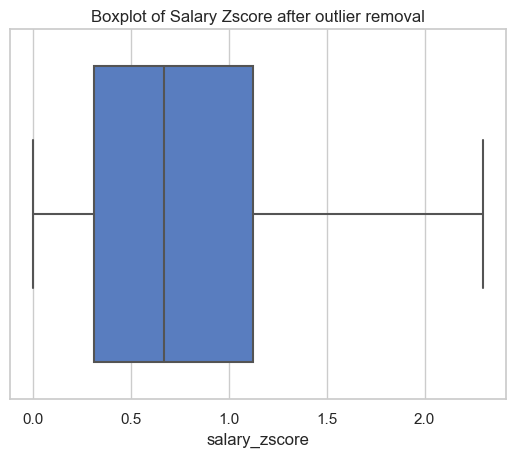

In [34]:
sns.boxplot(x= jobs_trimmed['salary_zscore'])
plt.title('Boxplot of Salary Zscore after outlier removal')
plt.show()

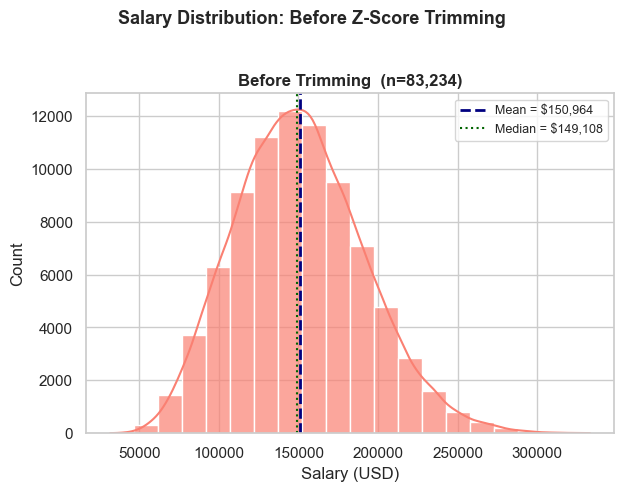

In [35]:
# visualize salary before and after trimming using a histogram subplots
fig, ax = plt.subplots()

sns.histplot(jobs_subset['salary'], bins=20, kde=True, ax= ax, color='salmon', edgecolor='white', alpha=0.7)
ax.axvline(jobs_subset['salary'].mean(), color='navy', linewidth=2, linestyle='--',
               label=f"Mean = ${jobs_subset['salary'].mean():,.0f}")
ax.axvline(jobs_subset['salary'].median(), color='darkgreen', linewidth=1.5, linestyle=':',
               label=f"Median = ${jobs_subset['salary'].median():,.0f}")
plt.title(f'Before Trimming  (n={n_before:,})', fontweight='bold')
plt.xlabel('Salary (USD)')
plt.legend(fontsize=9)

plt.suptitle('Salary Distribution: Before Z-Score Trimming', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

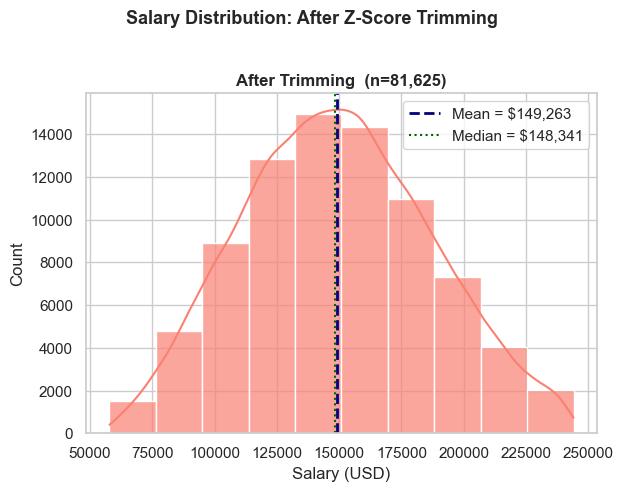

In [36]:
fig, ax = plt.subplots()

sns.histplot(jobs_trimmed['salary'], bins=10, kde=True, ax= ax, color='salmon', edgecolor='white', alpha=0.7)
ax.axvline(jobs_trimmed['salary'].mean(), color='navy', linewidth=2, linestyle='--',
               label=f"Mean = ${jobs_trimmed['salary'].mean():,.0f}")
ax.axvline(jobs_trimmed['salary'].median(), color='darkgreen', linewidth=1.5, linestyle=':',
               label=f"Median = ${jobs_trimmed['salary'].median():,.0f}")
plt.title(f'After Trimming  (n={n_after:,})', fontweight='bold')
plt.xlabel('Salary (USD)')
plt.legend(fontsize=11)

plt.suptitle('Salary Distribution: After Z-Score Trimming', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5. Exploratory Data Analysis (EDA)

*We will now visually explore the relationships between salary and the key features in our subset.*

In [37]:
# Create a new pipeline for EDA
# exclude the salary_zscore column 
jobs_trimmed_new = jobs_trimmed[['job_title','years_of_experience','experience_level',
           'education_level','skills_count', 'certifications',
           'skill_to_cert_ratio','industry', 'company_size','location',
           'remote_work', 'salary', 'salary_tier']]
jobs_trimmed_new.head(10)

,job_title,years_of_experience,experience_level,education_level,skills_count,certifications,skill_to_cert_ratio,industry,company_size,location,remote_work,salary,salary_tier
0,AI Engineer,10,Senior (8-13 yrs),Bachelor,2,2,0.67,Healthcare,Medium,India,Hybrid,109413,Low
1,Data Analyst,5,Mid-level (3-7 yrs),Bachelor,17,0,17.00,Telecom,Small,Australia,No,93764,Low
2,AI Engineer,0,Entry (0-2 yrs),High School,4,2,1.33,Education,Enterprise,USA,No,180351,High
3,Machine Learning Engineer,4,Mid-level (3-7 yrs),Bachelor,18,5,3.00,Healthcare,Enterprise,Canada,Hybrid,202463,High
4,AI Engineer,5,Mid-level (3-7 yrs),Diploma,14,0,14.00,Telecom,Enterprise,Singapore,Yes,171834,High
5,Data Analyst,3,Mid-level (3-7 yrs),Bachelor,3,4,0.60,Education,Startup,Singapore,Yes,87600,Low
6,Machine Learning Engineer,11,Senior (8-13 yrs),PhD,16,3,4.00,Consulting,Medium,Germany,Hybrid,191757,High
7,Data Scientist,2,Entry (0-2 yrs),Bachelor,14,5,2.33,Education,Startup,Remote,Yes,109478,Low
8,Data Scientist,13,Senior (8-13 yrs),Master,3,0,3.00,Government,Large,India,Yes,111158,Low
9,Machine Learning Engineer,15,Expert (14-20 yrs),PhD,15,5,2.50,Consulting,Medium,Germany,Hybrid,213920,Premium


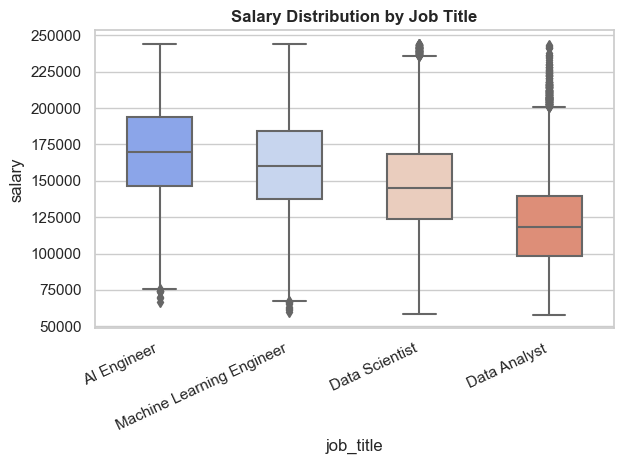

In [38]:
# What is the salary distribution by role (job_title)
# we will group the dataset by job_title and get their mean salary
salary_by_role = jobs_trimmed_new.groupby('job_title')['salary'].mean().sort_values(ascending = False).index

# Make a boxplot for the distribution
fig, ax = plt.subplots()
sns.boxplot(data=jobs_trimmed_new, x='job_title', y='salary', order=salary_by_role, ax=ax,
            palette='coolwarm', width=0.5)
ax.set_title('Salary Distribution by Job Title', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')

plt.tight_layout()
plt.show()

- The IQR spread of salaries for the job titles are very wide. This tells us that pay depends heavily on many other details, not just on role or job title.

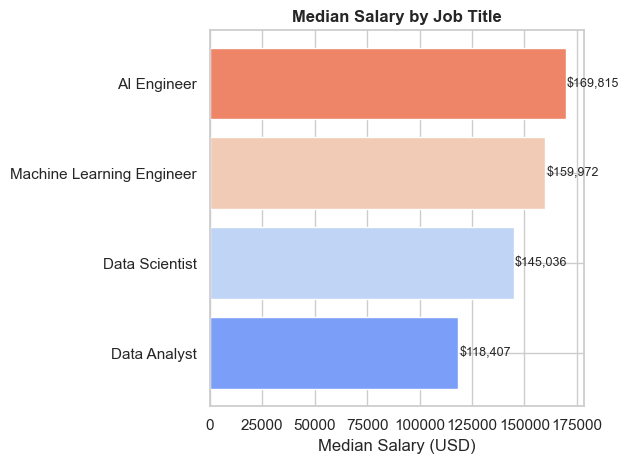

In [39]:
# make a median salary bar plot of the distribution
median_salary_by_role = jobs_trimmed_new.groupby('job_title')['salary'].median().sort_values(ascending = True)
fig, ax = plt.subplots()

bars = ax.barh(median_salary_by_role.index, median_salary_by_role.values, color=sns.color_palette('coolwarm', len(median_salary_by_role)), edgecolor='white')
plt.title('Median Salary by Job Title', fontweight='bold')
plt.xlabel('Median Salary (USD)')

for bar, val in zip(bars, median_salary_by_role.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)
# Places a text annotation on the chart at coordinates

plt.tight_layout()
plt.show()

- AI Engineers and Machine Learning Engineers earn the highest median salaries in this dataset, while Data Analysts are paid the least.
- This supports the box plot distribution.

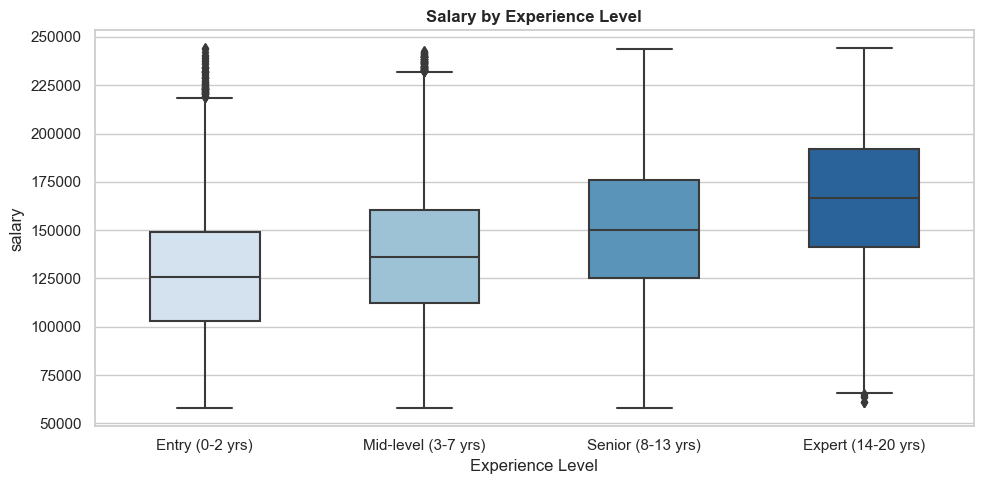

In [40]:
# What is the salary distribution per experience
# We will make a box plot for salary by experience_level
fig, ax = plt.subplots(figsize=(10, 5))

band_order = labels
sns.boxplot(data=jobs_trimmed_new, x='experience_level', y='salary', order=band_order,
            palette='Blues', ax=ax, width=0.5)
plt.title('Salary by Experience Level', fontweight='bold')
plt.xlabel('Experience Level'); axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

- The dataset shows a steady increase throughout a career.
- In all four job roles, the more experience you have, the higher your pay.
- Though, entry and mid levels contain outliers which might indicate that there are some persons in those experience level receiving similar salaries with their counterpart with higher experience level.
- An Expert earns about 40% more than someone who is just starting out in an entry-level position.

Text(0, 0.5, 'Salary (USD)')

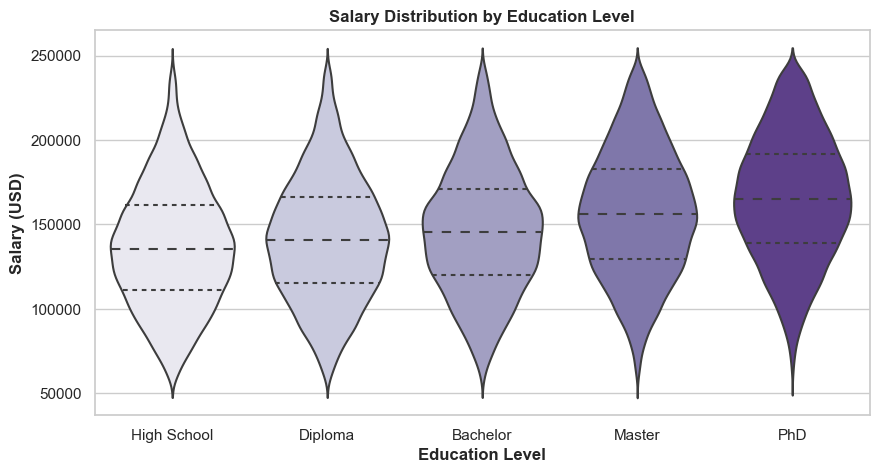

In [41]:
# What is the salary distribution per education level
# We will make a violin plot for this distribution
fig= plt.figure(figsize=(10, 5))
edu_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']

sns.violinplot(data=jobs_trimmed_new, x='education_level', y='salary', order=edu_order,
               palette='Purples', inner='quartile')
plt.title('Salary Distribution by Education Level', fontweight='bold')
plt.xlabel('Education Level', fontweight='bold')
plt.ylabel('Salary (USD)', fontweight='bold')

- The violin shapes are remarkably similar across education levels.
- While people with a PhD typically earn a little bit more, their pay is also less predictable, there is a much wider gap between the highest and lowest earners in that group compared to others.

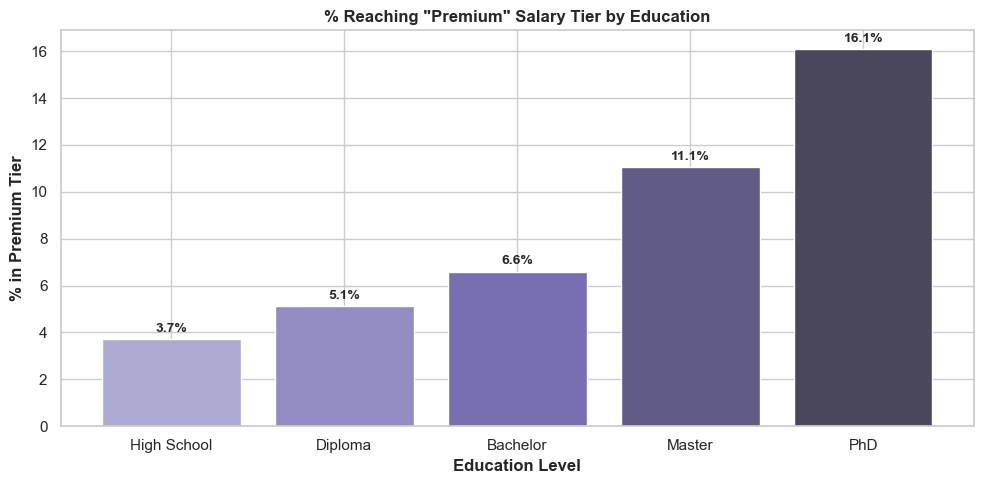

In [42]:
# Does having a higher education degree increase the chances of reaching the "premium" salary tier?
# we will plot the percentage of each education level that go to the premium salary tier
fig, ax = plt.subplots(figsize=(10, 5))

premium_pct = (jobs_trimmed_new.groupby('education_level').apply(
    lambda x: (x['salary_tier'] == 'Premium').mean() * 100).reindex(edu_order))

colors = sns.color_palette('Purples_d', len(premium_pct))
ax.bar(premium_pct.index, premium_pct.values, color=colors, edgecolor='white')
plt.title('% Reaching "Premium" Salary Tier by Education', fontweight='bold')
plt.xlabel('Education Level', fontweight='bold') 
plt.ylabel('% in Premium Tier', fontweight='bold')

for i, v in enumerate(premium_pct.values):# enumerate Loops through the percentage values while also tracking position.
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

- From the above plot, a higher degree increases the chances of reaching the premium salary tier.
- This does not guarantee dramatically a higher salary in tech given that professionals with lower degrees also attained the premium salary tier at some point in their career.
- This could mean thus far that job_title and experience matters more than credentials alone in the data/AI space.

location
USA           180,153.90
Canada        169,613.40
UK            163,860.64
Germany       158,561.08
Sweden        144,353.93
Netherlands   144,339.48
Singapore     144,309.33
Remote        144,263.79
Australia     144,217.44
India         102,194.37
Name: salary, dtype: float64


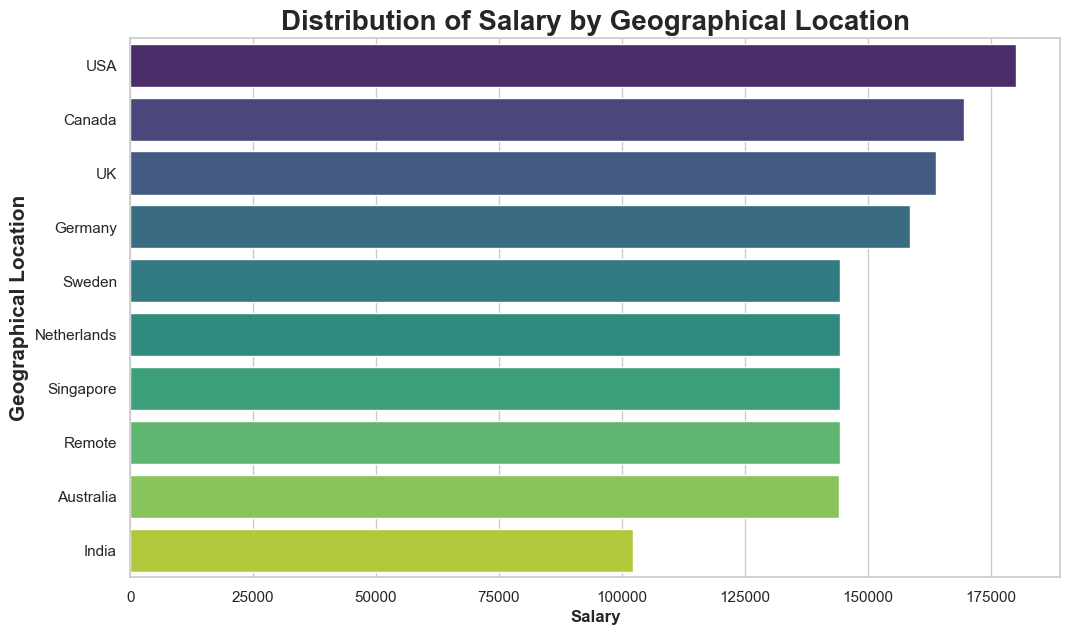

In [43]:
# What is the salary distribution across geographical locations
location_group = jobs_trimmed_new.groupby('location')['salary'].mean().sort_values(ascending = False)

print(location_group)
fig, ax = plt.subplots(figsize = (12,7))
sns.barplot(x = location_group.values, y = location_group.index, palette='viridis', orient = 'h')
plt.title('Distribution of Salary by Geographical Location', fontweight = 'bold', fontsize = 20)
plt.ylabel('Geographical Location', fontweight = 'bold', fontsize = 15)
plt.xlabel('Salary', fontweight = 'bold')
plt.show()

- The USA pays the most for data professionals at around 180,000, followed by Canada, UK, and Germany in that order. These four countries clearly stand out as the highest paying locations.

- In the middle, Sweden, Netherlands, Singapore, Remote, and Australia all pay almost exactly the same amount at around 143,000– 145,000. 

- This is surprising because these are very different parts of the world, yet they have landed on nearly the same salary level for data roles.

- India pays the least at around 103,000, which is noticeably lower than every other location in the dataset.

*Location is a strong salary differentiator at the extremes. The USA clearly dominates at the top while India sits at the bottom. However, the middle cluster of five locations tells us that beyond the top four, geography alone stops being a meaningful differentiator.**

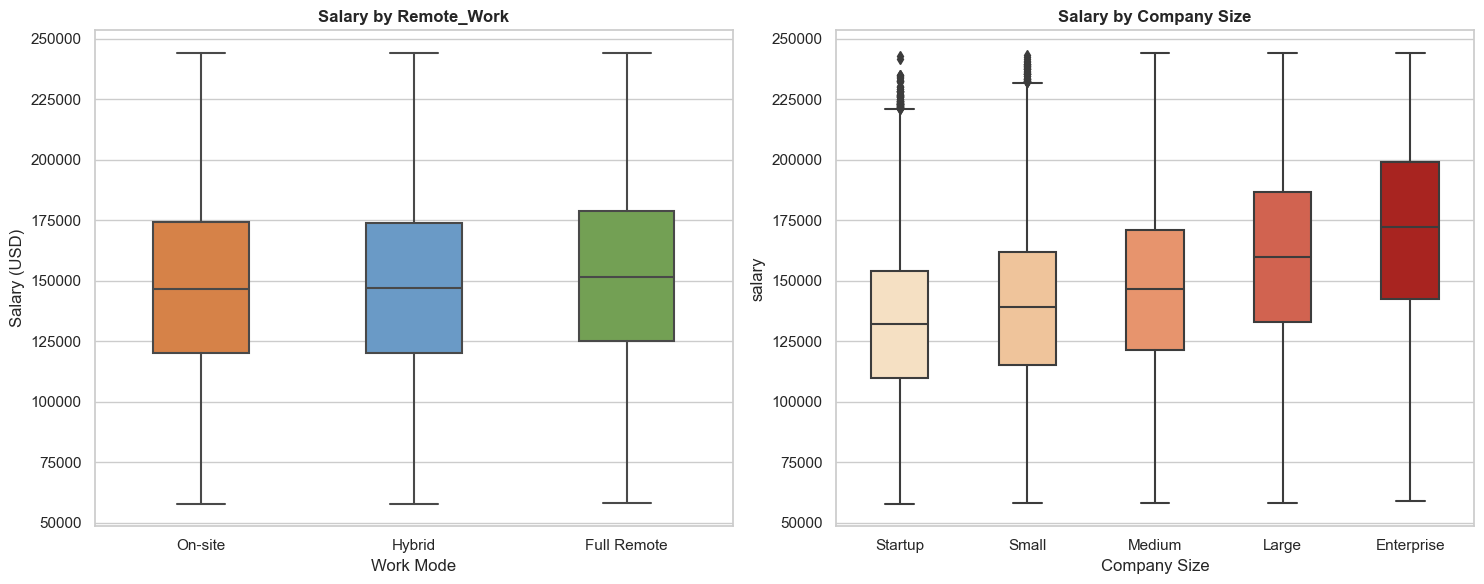

In [44]:
# How does remote_work and company_size impact salary
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Remote work vs salary distribution
remote_map = {'No': 'On-site', 'Hybrid': 'Hybrid', 'Yes': 'Full Remote'}
jobs_trimmed_new['remote_label'] = jobs_trimmed_new['remote_work'].map(remote_map)
remote_order = ['On-site', 'Hybrid', 'Full Remote']

sns.boxplot(data=jobs_trimmed_new, x='remote_label', y='salary', order=remote_order,
            palette=['#ED7D31','#5B9BD5','#70AD47'], ax=axes[0], width=0.45)
axes[0].set_title('Salary by Remote_Work', fontweight='bold')
axes[0].set_xlabel('Work Mode')
axes[0].set_ylabel('Salary (USD)')

# Company size vs salary distribution
size_order = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']
sns.boxplot(data=jobs_trimmed_new, x='company_size', y='salary', order=size_order,
            palette='OrRd', ax=axes[1], width=0.45)
axes[1].set_title('Salary by Company Size', fontweight='bold')
axes[1].set_xlabel('Company Size')

plt.tight_layout()
plt.show()

**Salary by work mode**
- Full Remote has the highest median of the three work mode, but only marginally so.
- All three work mode share the same whisker range so extreme high and low earners exist across every work mode equally.
- This could mean that work mode alone does not necessarily determine salary.

**Salary by company size**
- There is an upward trend in median salary across company sizes. Startup have the lowest median salary while enterprise have highest median salaries.
- Interestingly, Startup and Small companies show a significant number of high-end outliers.
- This might suggests that while these companies generally pay less, a select few individuals in smaller firms are earning significantly more than their peers, sometimes reaching the same levels as Enterprise top-earners.

*Betwwen work mode and company size, company size is a stronger predictor of salary*

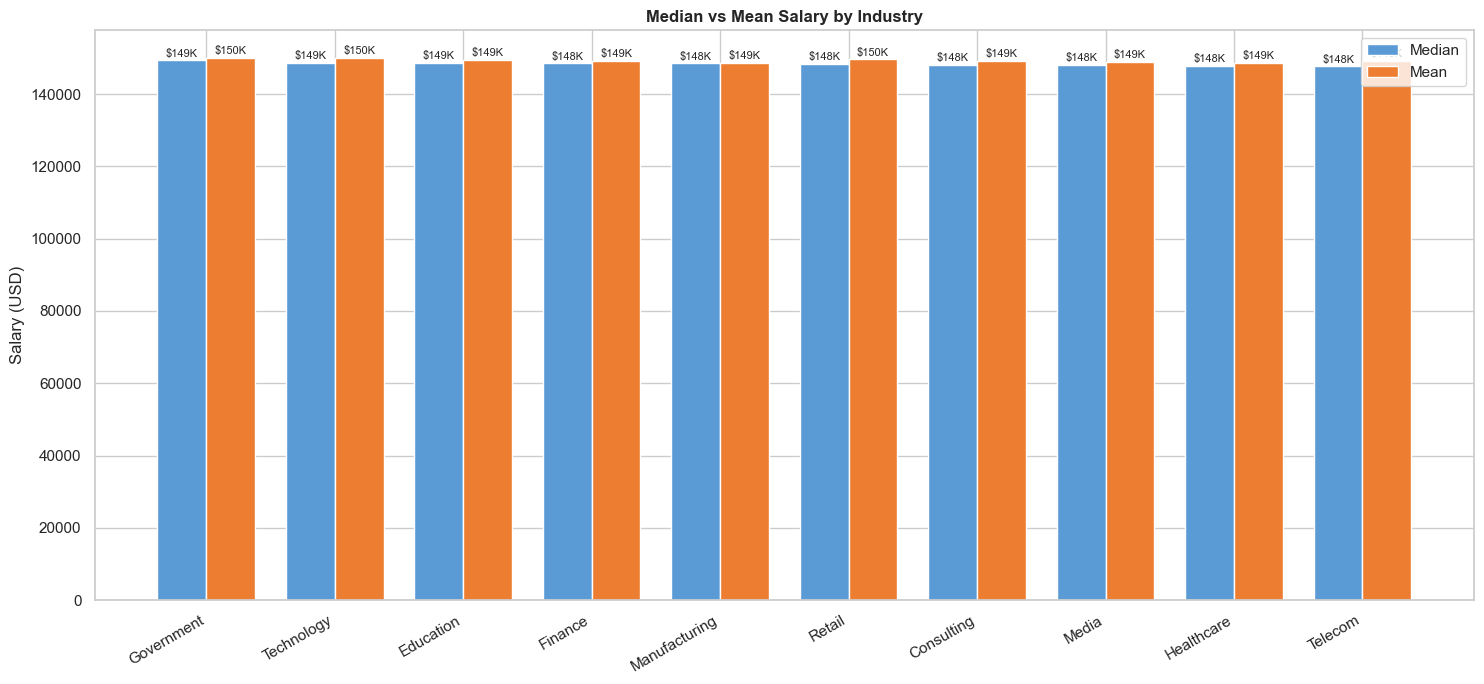

In [45]:
# what is the salary distribution per industry
fig, ax = plt.subplots(figsize=(15, 7))

industry_stats = (jobs_trimmed_new.groupby('industry')['salary']
                    .agg(['median','mean'])
                    .sort_values('median', ascending=False))

x = np.arange(len(industry_stats)) 
# This creates an array that includes one integer position per industry on the x-axis
width = 0.38

bars1 = ax.bar(x - width/2, industry_stats['median'], width, label='Median', color='#5B9BD5', edgecolor='white')
bars2 = ax.bar(x + width/2, industry_stats['mean'],   width, label='Mean',   color='#ED7D31', edgecolor='white')
# This places the median and mean bar side by side

ax.set_xticks(x)
ax.set_xticklabels(industry_stats.index, rotation=30, ha='right')
ax.set_title('Median vs Mean Salary by Industry', fontweight='bold')
ax.set_ylabel('Salary (USD)')
ax.legend()

for bar in bars1: # This helps with the annotation of values on the bars
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${bar.get_height()/1000:.0f}K', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${bar.get_height()/1000:.0f}K', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

- The median and mean are very similar across all industries.
- The technology industry has the highest mean salary of about 150K usd.
- Because the average and the middle value are very similar across all industries, we can tell that adjusting the extreme data points successfully reduced the impact of outliers.

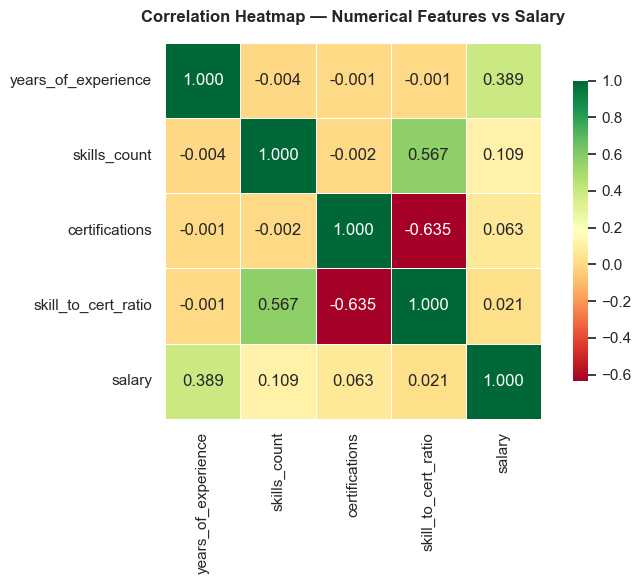

In [59]:
# Generate a heat map to measure the correlation of columns

jobs_corr = jobs_trimmed_new.copy()

corr_matrix = jobs_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f',
            cmap='RdYlGn', square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features vs Salary', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

- Years_of_experience shows the strongest positive correlation with salary among all numerical features.
- Intrestingly, skills_count and certifications have relatively weak correlations with salary. 
- This might mean, simply having many skills or certificates alone does not necessarily mean higher pay.
- Hence, thus far, job_title and years_of_experience seem to matter more because they reflect how well and for how long the skills are being put to use.

### 6. Use NumPy

**Numpy Computations**

In [61]:
# let's obtain the salaries for each job_title in the target_roles variable using Numpy
print(f"{'Role':<35} {'Mean ($)':>10} {'Std Dev ($)':>12}")
for role in sorted(target_roles):
    salary_arr = jobs_trimmed_new.loc[jobs_trimmed_new['job_title'] == role, 'salary'].to_numpy()
    role_mean  = np.mean(salary_arr)
    role_std   = np.std(salary_arr, ddof=1)           
    # ddof = 1 tells numpy to calculate the sample std rather than the population one
    role_min   = np.min(salary_arr)
    role_max   = np.max(salary_arr)
    print(f"{role:<35} ${role_mean:>9,.0f} ${role_std:>11,.0f}")

Role                                  Mean ($)  Std Dev ($)
AI Engineer                         $  169,684 $     33,797
Data Analyst                        $  120,477 $     30,158
Data Scientist                      $  146,647 $     33,266
Machine Learning Engineer           $  160,885 $     34,269


In [62]:
# obtain the full dataset figures using numpy
all_salaries = jobs_trimmed_new['salary'].to_numpy()
print(f"Overall Mean Salary : ${np.mean(all_salaries):>10,.2f}")
print(f"Overall Std Deviation: ${np.std(all_salaries, ddof=1):>10,.2f}")
print(f"Overall Median: ${np.median(all_salaries):>10,.2f}")
print(f"Percentile [10, 50, 90]: {np.percentile(all_salaries, [10, 50, 90])}")

Overall Mean Salary : $149,263.43
Overall Std Deviation: $ 37,801.00
Overall Median: $148,341.00
Percentile [10, 50, 90]: [ 99727.2 148341.  200505.4]


**Numpy Simulation**

In [49]:
# Using the observed mean and std of data scientist
# let's simulate an hypothethtical salary offers for a 1,000,000 professionals
# What percentage of simulated salaries exceed $200,000?
# What percentage fall below $100,000?
# Assumption: Simulated salary approximately equals normal salary
np.random.seed(2026) # This ensures the simulation produces the same result everytime the notebook is run

ds_salaries = jobs_trimmed_new.loc[jobs_trimmed_new['job_title'] == 'Data Scientist', 'salary'].to_numpy()
mu_ds  = np.mean(ds_salaries)
std_ds = np.std(ds_salaries, ddof=1)

simulated = np.random.normal(loc=mu_ds, scale=std_ds, size=1_000_000)
simulated = np.clip(simulated, 30_000, 400_000)   # limits the values in the array

p_over_200k = np.mean(simulated > 200_000) * 100
p_under_100k = np.mean(simulated < 100_000) * 100

print(f"Salary Simulation for Data Scientist (n=1,000,000 draws)")
print(f" Observed mean(μ) = ${mu_ds:,.0f}")
print(f" Observed std (σ) = ${std_ds:,.0f}")
print(f" {p_over_200k:.2f}% of the simulated salary exceeds $200,000")
print(f" {p_under_100k:.2f}% of the simulated salary falls below $100,000")

Salary Simulation for Data Scientist (n=1,000,000 draws)
 Observed mean(μ) = $146,647
 Observed std (σ) = $33,266
 5.40% of the simulated salary exceeds $200,000
 8.04% of the simulated salary falls below $100,000


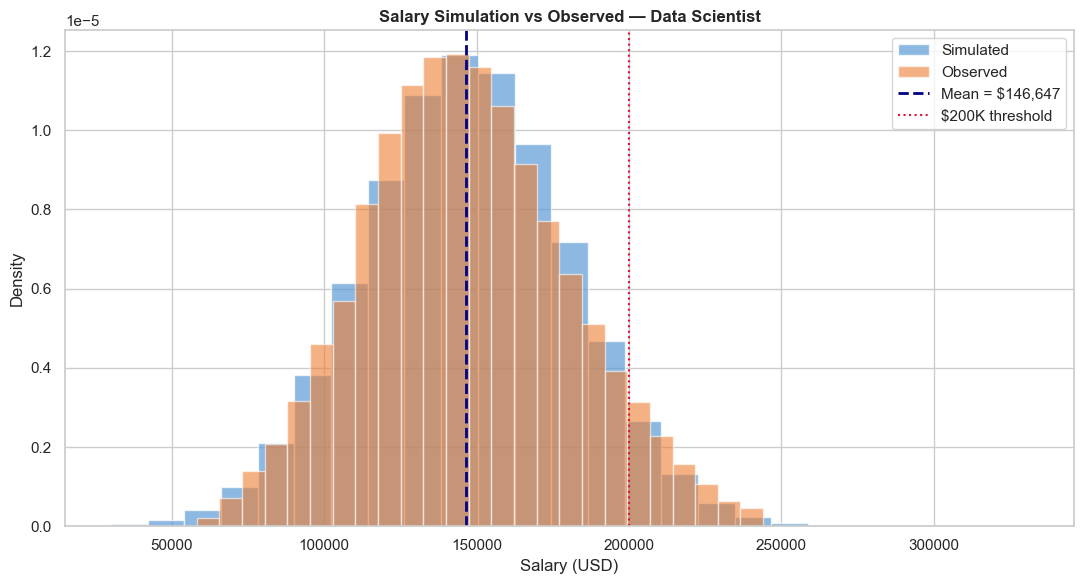

In [64]:
# Make a plot for the simulation
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(simulated, bins=25, density=True, color='#5B9BD5', edgecolor='white', alpha=0.7, label='Simulated')
ax.hist(ds_salaries, bins=25, density=True, color='#ED7D31', edgecolor='white', alpha=0.6, label='Observed')
ax.axvline(mu_ds, color='navy', linewidth=2, linestyle='--', label=f'Mean = ${mu_ds:,.0f}')
ax.axvline(200_000, color='crimson', linewidth=1.5, linestyle=':', label='$200K threshold')
plt.title('Salary Simulation vs Observed — Data Scientist', fontweight='bold')
plt.xlabel('Salary (USD)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

- The simulated distribution closely mirrors observed salary data,validating the normality assumption for the Data Scientist role.
- Data Scientist has roughly a 5.40% probability of earning above 200K.
- A knowledge about this can be useful for salary negotiation.

### 7. Introductory Inferential Statistics 

**Background**

- Throughout our analysis, most observation has pointed back to years_of_experience as the dominant salary driver.
- Stronger than education_level, skills_count, certifications, work mode, or company size.
- Location is also a driver of salary, but from analysis beyond four extreme countries (US, Canada, UK, and Germany) location alone stops being a meaningful differentiator. Hence, for this inferential analysis, we will assume its effect is negligible.
- We will now test years_of_experience as the dominant salary driver with inferential statistics.

*Hypothesis*
- More experienced data professionals earn significantly more.

*Business question*
- Do data professionals with above-average experience earn a mean salary that is significantly higher than the overall dataset mean?

*Null Hypothesis (H0)*
- The mean salary of senior professionals (above-average experience) is equal to the overall mean salary.
- Experience makes no significant difference.

*Alternative Hypothesis (H1)*
- The mean salary of senior professionals is significantly greater than the overall mean salary.

In [51]:
# Define the two groups
# Senior = professionals with above-average experience years
# Overall mean = benchmark salary for the entire working dataset

avg_experience = jobs_trimmed_new['years_of_experience'].mean()
overall_mean = jobs_trimmed_new['salary'].mean()

senior_mask = jobs_trimmed_new['years_of_experience'] > avg_experience
senior_salaries = jobs_trimmed_new.loc[senior_mask, 'salary'].to_numpy()

print(f"--Group Summary")
print(f" Average experience in dataset : {avg_experience:.2f} years")
print(f" Senior = years_of_experience > {avg_experience:.2f} years")
print(f" Senior professionals count : {len(senior_salaries):,}")
print(f" Overall dataset mean salary : ${overall_mean:,.2f}")
print(f" Senior group mean salary : ${np.mean(senior_salaries):,.2f}")

--Group Summary
 Average experience in dataset : 9.93 years
 Senior = years_of_experience > 9.93 years
 Senior professionals count : 42,473
 Overall dataset mean salary : $149,263.43
 Senior group mean salary : $161,495.94


In [65]:
# Perform One-Sample T-Test
# significance level = 0.05
# we will make use of the one-tailed test
# A one-tailed test is appropriate when prior evidence already tells us the direction of the expected difference
# Our EDA already showed a clear upward direction of experience and salary move together positively. 

t_statistic, p_value_two_tailed = ttest_1samp(senior_salaries, overall_mean)
p_value_one_tailed = p_value_two_tailed / 2

print(f"One-Sample t-Test Results")
print(f"Population mean : ${overall_mean:,.2f}")
print(f"Sample mean (senior group) : ${np.mean(senior_salaries):,.2f}")
print(f"Difference : ${np.mean(senior_salaries) - overall_mean:,.2f}")
print(f"Sample size : {len(senior_salaries):,}")
print(f"t-statistic : {t_statistic:.4f}")
print(f"p-value (two-tailed) : {p_value_two_tailed:.6f}")
print(f"p-value (one-tailed) : {p_value_one_tailed:.6f}")
print(f"Significance level : 0.05")

One-Sample t-Test Results
Population mean : $149,263.43
Sample mean (senior group) : $161,495.94
Difference : $12,232.51
Sample size : 42,473
t-statistic : 69.5737
p-value (two-tailed) : 0.000000
p-value (one-tailed) : 0.000000
Significance level : 0.05


In [53]:
if p_value_one_tailed < 0.05 and t_statistic > 0:
    print("REJECT Null Hypothesis: Senior professionals earn significantly MORE than the overall mean.")
    print("\nExperience is a statistically significant driver of salary.")
elif p_value_one_tailed < 0.05 and t_statistic < 0:
    print("REJECT Null Hypothesis: Senior professionals earn significantly LESS than the overall mean.")
else:
    print("FAIL TO REJECT H0: No significant salary difference for senior professionals.")

REJECT Null Hypothesis: Senior professionals earn significantly MORE than the overall mean.

Experience is a statistically significant driver of salary.


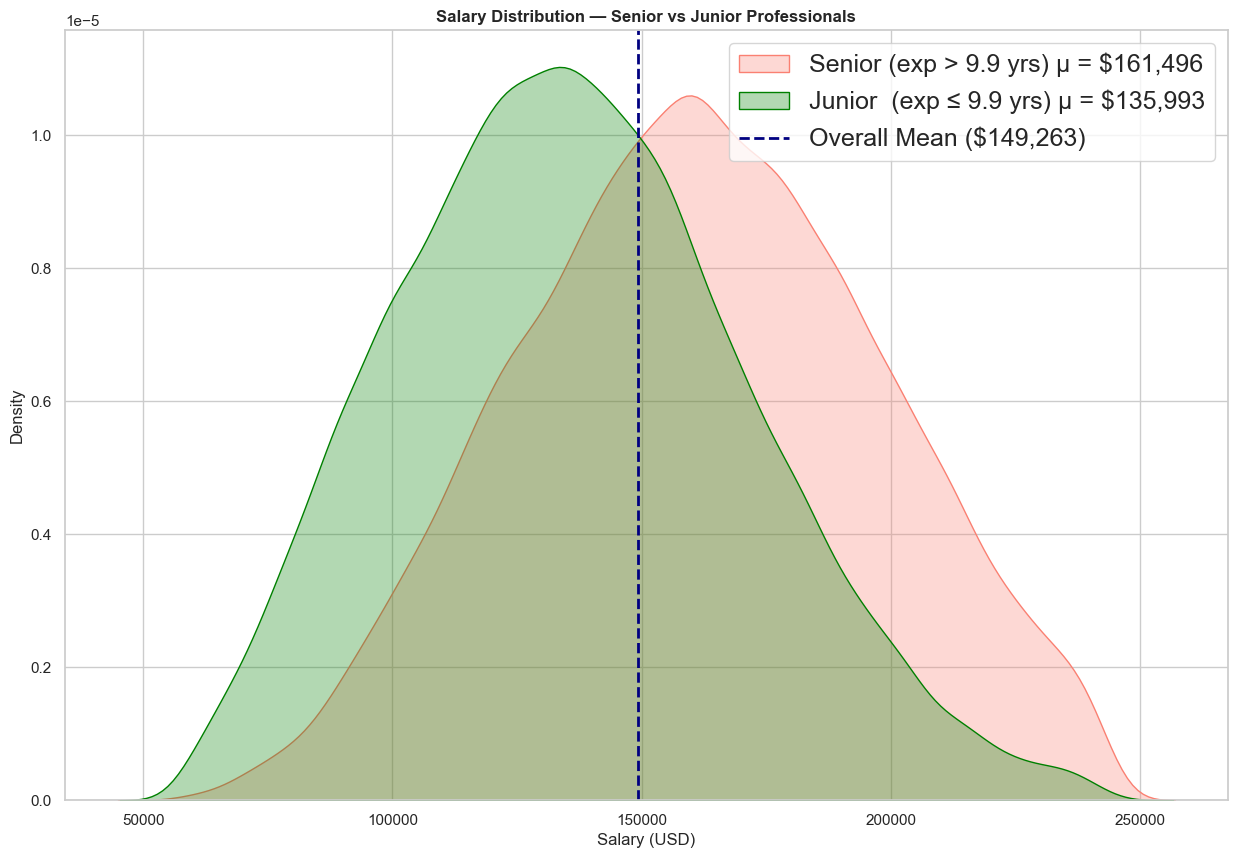

In [54]:
# let's visualize the hypothesis test using a KDE plot

fig, ax = plt.subplots(figsize=(15, 10))
junior_salaries = jobs_trimmed_new.loc[~senior_mask, 'salary'].to_numpy()

for label, data, color in [
    (f'Senior (exp > {avg_experience:.1f} yrs)', senior_salaries, 'salmon'),
    (f'Junior  (exp ≤ {avg_experience:.1f} yrs)', junior_salaries,  'green')
]:
    sns.kdeplot(data, label=f"{label} μ = ${np.mean(data):,.0f}",
                fill=True, alpha=0.3, color=color)

ax.axvline(overall_mean, color='navy', linestyle='--', linewidth=2,
                label=f'Overall Mean (${overall_mean:,.0f})')
plt.title('Salary Distribution — Senior vs Junior Professionals', fontweight='bold')
plt.xlabel('Salary (USD)')
plt.ylabel('Density')
plt.legend(fontsize=18)
plt.show()

**Test Result Interpretation**
- The p-value is 0 which is less than the significance level (0.05) and the t-statistic value is 69.5737 which is greater than 0.
- Hence, there is significant statistical evidence to conclude that senior data professionals earn significantly more than the overall average.
- This confirms what the EDA suggests; Experience is not just correlated with salary, it has a statistical significant effect on it.
- The KDE plot shows the full salary distribution of both groups. A clear rightward shift in the senior group's curve relative to the junior group confirms the direction of the difference visually.

*NB: Senior is defined as above-average experience years, not by job title or salary tier. So the group still contains a mix of roles and industries.*

### Conclusion and Key Findings

1. **Experience is the number one salary driver**: This is proven by the strongest positive numerical correlation with salary in the heatmap and also confirmed by the t-test.

2. **Location is also a salary driver, but, only in the US, Canada, UK, and Germany. Beyond these extremes, it fails to be a differentiator.**: We can see this in the horizontal bar plot of Distribution of Salary by Geographical Location.

3. **Senior professionals earn significantly more**: This is proven by the rejection of the null hypothesis at a significance level of 5% from the one-sample t-test.

4. **AI & ML roles command higher salaries than Data careers**: This is proven in the box and bar plot of median salaries across job_title.

5. **Company size is a stronger salary predictor than work mode**: This is shown in the box subplots of work mode and company size vs salary. There is a clear upward trend from Startup to Enterprise while work mode differences are marginal.

6. **Skills and certifications alone do not drive salary**: This is shown by the weak positive correlations with salary relative to experience.